In [11]:
import random as random
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')
import os


In [116]:
def chuanhoa_chuyendong(a,b,N):
    delta_x= []
    delta_y= []

    for i in range(N):
        delta_x_star = np.random.uniform(a,b)
        delta_y_star = np.random.uniform(a,b)
        L_star = np.sqrt(delta_x_star**2 + delta_y_star**2)

        delta_x_norm = delta_x_star/L_star
        delta_y_norm = delta_y_star/L_star

        delta_x.append(delta_x_norm)
        delta_y.append(delta_y_norm)
    return delta_x, delta_y

def toado_moilan_chuyendong(a,b,N,x0,y0):
    x = []
    y = []
    x.append(x0)
    y.append(y0)

    delta_x, delta_y = chuanhoa_chuyendong(a,b,N)
    for i in range(1,N):
        x.append(x[-1] + delta_x[i])
        y.append(y[-1] + delta_y[i])
    
    return x, y

def luu_file_toado(x_list, y_list, filename_i,foldername,filename_mau):
    if not os.path.exists(foldername):
        os.makedirs(foldername)
    with open(filename_mau+str(filename_i+1)+".txt", "w", encoding="utf-8") as file:
        file.write(f"# File chua thong tin toa do tai lan chay thu {filename_i+1}\n")
        file.write("#" * 90 + "\n")
        file.write(f"#{'Step':>6s}  {'x':>18s}  {'y':>18s} {'delta_x':>18s} {'delta_y':>18s}\n")
        for i in range(len(x_list)):
            delta_x = x_list[i] - x_list[i-1] if i > 0 else 0
            delta_y = y_list[i] - y_list[i-1] if i > 0 else 0
            file.write(f"{i+1:6d}  {x_list[i]:18.12f}  {y_list[i]:18.12f}  {delta_x:18.12f}  {delta_y:18.12f}\n")

a = -1
b =  1
N = 1000
x0 = y0 = 0
number_of_RDW = np.sqrt(N).astype(int)
foldername = "./datatoado"
filename = foldername+"/toado_lan_"

for i in range(number_of_RDW):
    x_list, y_list = toado_moilan_chuyendong(a, b, N, x0, y0)
    luu_file_toado(x_list, y_list, i,foldername,filename)

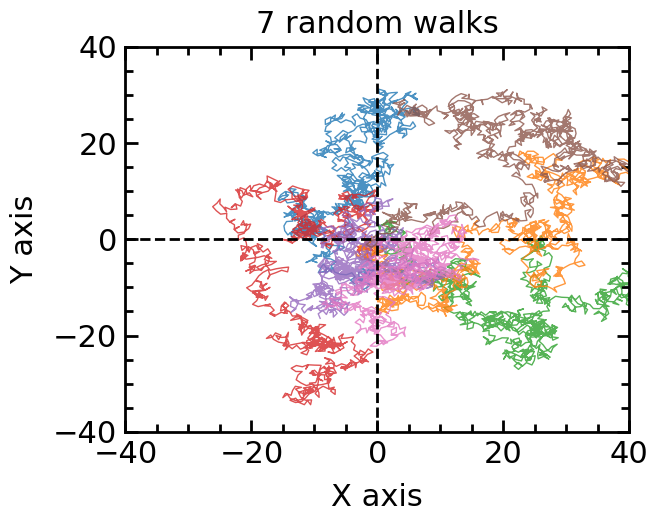

In [169]:
plt.Figure(figsize=(8,8))

number_of_RDW_plot = 7

for i in range(1, number_of_RDW_plot + 1):
    step, x, y, delta_x, delta_y = np.loadtxt(
        "./datatoado/toado_lan_" + str(i) + ".txt",
        unpack=True,
        comments="#"
    )
    plt.plot(x, y, linewidth=1, label=f"Lan {i}", color = f"C{i-1}", alpha = 0.8)

plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.axvline(0, lw=2, linestyle = "--",color = "black")
plt.axhline(0, lw=2, linestyle = "--",color = "black")

plt.title("7 random walks")

plt.xlim(-40,40)
plt.ylim(-40,40)
plt.savefig("Hinh_so_1.pdf")
plt.show()

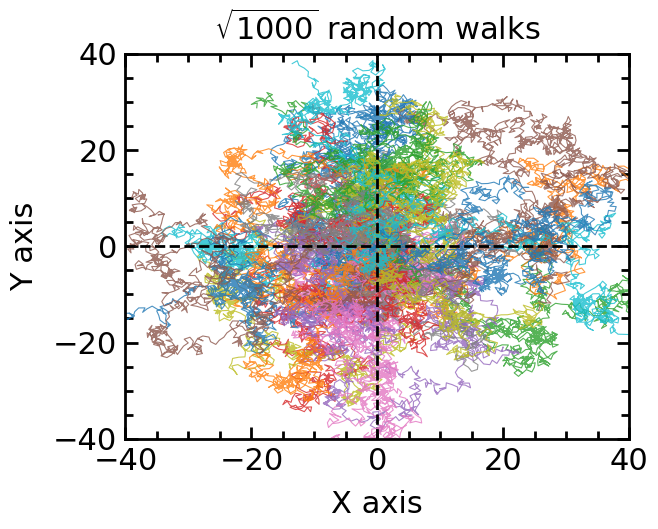

In [118]:
plt.Figure(figsize=(8,8))

number_of_RDW_plot = number_of_RDW

for i in range(1, number_of_RDW_plot + 1):
    step, x, y, delta_x, delta_y = np.loadtxt(
        "./datatoado/toado_lan_" + str(i) + ".txt",
        unpack=True,
        comments="#"
    )
    plt.plot(x, y, linewidth=0.8, label=f"Lan {i}", alpha = 0.8)

plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.axvline(0, lw=2, linestyle = "--",color = "black")
plt.axhline(0, lw=2, linestyle = "--",color = "black")

plt.title(rf"$\sqrt{{{N}}}$ random walks")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.savefig("Hinh_so_2.pdf")

plt.show()

In [ ]:
def tinh_khoangcachbinhphuong(number_of_RDW,filename):
    with open(f"Khoang_cach_binh_phuong_cua_{number_of_RDW}_lan_thu.txt", "w", encoding="utf-8") as file:
        file.write(f"# Khoang cach binh phuong (R^2) cua {number_of_RDW}_lan_thu\n")
        file.write("#" * 120 + "\n")
        file.write(f"#{'Lan thu:':>8s} {'x(dau)':>20s} {'y(dau)':>20s} {'x(cuoi)':>20s} {'y(cuoi)':>20s} {'R^2':>20s}\n")
        # Tinh tong R^2 cho tung lan chay
        R2_total = 0
        for i in range(1, number_of_RDW + 1):
            x, y = np.loadtxt(filename + str(i) + ".txt", unpack=True, comments="#", usecols=(1, 2))
            d = (x[-1] - x[0])**2 + (y[-1] - y[0])**2
            R2_total += d
            file.write(f"{i:8.0f} {x[0]:20.12f} {y[0]:20.12f} {x[-1]:20.12f} {y[-1]:20.12f} {d:20.12f}\n")
        # Tinh trung binh R^2
        R2_mean = R2_total / number_of_RDW
        file.write("#" * 120 + "\n")
        file.write(f"# Tong tat ca R^2 cua {number_of_RDW} trials: {R2_total:.12f}\n")
        file.write(f"# Trung binh R^2: {R2_mean:.12f}#")
        print(f"Trung binh R^2 sau {number_of_RDW} lan chay: {R2_mean:.12f}")
    return R2_mean, R2_total

tinh_khoangcachbinhphuong(number_of_RDW, filename)

IndentationError: unindent does not match any outer indentation level (<string>, line 30)

In [120]:
def tinh_crossterm_single_trial(N,filename,i,type):
    x, y, delta_x, delta_y = np.loadtxt(filename + str(i) + ".txt", unpack=True, comments="#", usecols=(1,2,3,4))
    crossterm = 0
    R2 = (x[-1] - x[0])**2 + (y[-1] - y[0])**2
    if type == "xx":
        weight = N*(N-1)
        for i in range(1,len(delta_x)):
            for j in range(i):
                if i != j:
                    crossterm = crossterm + delta_x[i] * delta_x[j]
        average_crossterm = crossterm / (weight*R2)
    elif type == "xy":
        weight = N**2
        for i in range(1,len(delta_x)):
            for j in range(i):
                    crossterm = crossterm + delta_x[i] * delta_y[j]
        average_crossterm = crossterm / (weight*R2)
    return average_crossterm
# Test
tinh_crossterm_single_trial(N, filename,1, "xx")

np.float64(-5.19599489794391e-07)

In [ ]:
def tinh_tong_trung_binh_crossterm(N, number_of_RDW, filename_toado):
    crossterm_xx_total = 0
    crossterm_xy_total = 0
    with open(f"Tinh_tong_trung_binh_cross_term_cua{number_of_RDW} lan thu.txt", "w", encoding="utf-8") as file:
        file.write(f"# Tinh tong trung binh cross term cua {number_of_RDW}_lan_thu\n")
        file.write("#" * 120 + "\n")
        file.write(f"#{'Lan thu:':>8s} {'crossterm (xx)':>20s} {'crossterm (xy)':>20s}\n")
        for i in range(1, number_of_RDW + 1):
            crossterm_xx = tinh_crossterm_single_trial(N, filename_toado, i, "xx")
            crossterm_xy = tinh_crossterm_single_trial(N, filename_toado, i, "xy")
            crossterm_xx_total += crossterm_xx
            crossterm_xy_total += crossterm_xy   
            file.write(f"{i:8.0f} {crossterm_xx:20.12f} {crossterm_xy:20.12f}\n")
        crossterm_xx_mean = crossterm_xx_total / number_of_RDW
        crossterm_xy_mean = crossterm_xy_total / number_of_RDW

        file.write("#" * 120 + "\n")
        file.write(f"# Trung binh crossterm (xx): {crossterm_xx_mean:.12f}#\n")
        file.write(f"# Trung binh crossterm (xy): {crossterm_xy_mean:.12f}#\n")
    print(f"Trung binh crossterm (xx) sau {number_of_RDW} lan chay: {crossterm_xx_mean:.12f}")
    print(f"Trung binh crossterm (xy) sau {number_of_RDW} lan chay: {crossterm_xy_mean:.12f}")

tinh_tong_trung_binh_crossterm(N,number_of_RDW,filename)

Trung binh crossterm (xx) sau 31 lan chay: -0.000000567803
Trung binh crossterm (xy) sau 31 lan chay: 0.000000090372


In [155]:
def tinh_khoangcachbinhphuong_khongfile(N):
    global x0, y0, a, b
    number_of_RDW = max(1, np.sqrt(N).astype(int))
    # Tinh tong R^2 cho tung lan chay
    R2_total = 0
    for i in range(1, number_of_RDW + 1):
        x, y = toado_moilan_chuyendong(a, b, N, x0, y0)
        d = (x[-1] - x[0])**2 + (y[-1] - y[0])**2
        R2_total += d
    # Tinh trung binh R^2
    R2_mean = R2_total / number_of_RDW
    return R2_mean

def khaosat_R_theo_sqrt_N(N_min,N_max):
    with open(f"Tuong_quan_giua_sqrt(R2_mean)_voi_sqrt(N).txt", "w", encoding="utf-8") as file:
        file.write(f"# Tuong quan giua sqrt(R2_mean) voi sqrt(N)\n")
        file.write("#" * 60 + "\n")
        file.write(f"#{'N:':>8s} {'sqrt(N)':>20s} {'R_mean':>20s}\n")
        for N in range(N_min,N_max,10):
            R2_mean = tinh_khoangcachbinhphuong_khongfile(N)
            R_mean = np.sqrt(R2_mean)
            file.write(f"{N:8.0f} {np.sqrt(N):20.12f} {R_mean:20.12f}\n")

N_min = 1 
N_max = 10000
khaosat_R_theo_sqrt_N(N_min,N_max)

KeyboardInterrupt: 

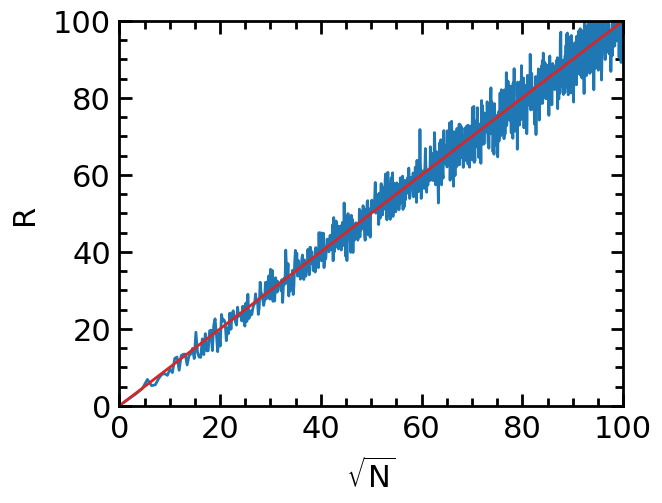

In [170]:
plt.Figure(figsize=(8,8))

sqrt_N, R_mean = np.loadtxt(f"Tuong_quan_giua_sqrt(R2_mean)_voi_sqrt(N).txt", unpack=True, comments="#", usecols=(1,2))
x_plot = np.linspace(0,300)
plt.plot(sqrt_N,R_mean, color = "C0")
plt.plot(x_plot,x_plot,color = "C1")
plt.xlim(0,100)
plt.ylim(0,100)

plt.xlabel(r"$\sqrt{N}$")
plt.ylabel("R")


plt.savefig("Ho")